# Cattle Muzzle Individual Dataset Analysis

This notebook provides a comprehensive analysis of the **Cattle Muzzle Individual** dataset. Cattle muzzle print patterns are unique biometrics (analogous to human fingerprints) that can be used for individual cattle identification. This notebook covers:
1. **Dataset Importing & Loading** (supports both the full 268-cow dataset and the local 24-cow subset).
2. **Cattle Profiling**: Mapping all cattle IDs, counts of images per ID, and identifying the minimum/maximum images per cow.
3. **Data Visualization**: Histogram of the image count distribution and a grid of sample muzzle prints.
4. **Known/Unknown Separation**: Grouping cows based on a threshold of `10` images (cows with < 10 images are unknown, >= 10 are known), exporting lists to CSVs, and importing them back.
5. **Duplicate Image Detection**: Scanning for exact duplicate files based on MD5 checksums.
6. **Train/Validation/Test Split**: Allocating known cows' images (70% train, 15% validation, 15% test) and placing unknown cows' images entirely into the test set.
7. **Split Integrity Analysis**: Verifying representation of known cows across splits and generating overall dataset split statistics.

In [1]:
import os
import zipfile
import hashlib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Import and Resolve Dataset

We search for the full `BeefCattle_Muzzle_Individualized` dataset in the workspace. If it is not present, we attempt to download it from Zenodo. If the download fails or isn't possible, we fallback to the local `Cattle Muzzle - DB` folder.

In [2]:
import os

DATA_DIR = "BeefCuzzle_Muzzle_Individualized" if os.path.exists("BeefCuzzle_Muzzle_Individualized") else "BeefCattle_Muzzle_Individualized"

def resolve_dataset_dir(path):
    current = path
    while True:
        items = [i for i in os.listdir(current) if not i.startswith('.')]
        if len(items) == 1 and os.path.isdir(os.path.join(current, items[0])):
            current = os.path.join(current, items[0])
        else:
            break
    return current

DATA_DIR = resolve_dataset_dir(DATA_DIR)
print(f"Resolved Dataset Directory: {DATA_DIR}")

Resolved Dataset Directory: BeefCattle_Muzzle_Individualized/BeefCattle_Muzzle_Individualized


## 2. Load Dataset Files and Print Image Counts per Cow ID

We collect image file paths from both pre-split or flat folder layouts, group them by cow ID, and print the counts of images for all cows.

In [3]:
def collect_images_by_class(data_dir):
    class_images = {}
    has_splits = all(os.path.exists(os.path.join(data_dir, s)) for s in ['train', 'val', 'test'])
    
    if has_splits:
        print(f"Detected pre-split splits under '{data_dir}'. Merging image paths...")
        splits = ['train', 'val', 'test']
        class_names = set()
        for s in splits:
            split_dir = os.path.join(data_dir, s)
            if os.path.exists(split_dir):
                for d in os.listdir(split_dir):
                    if os.path.isdir(os.path.join(split_dir, d)) and not d.startswith('.'):
                        class_names.add(d)
        class_names = sorted(list(class_names))
        
        for cls in class_names:
            class_images[cls] = []
            for s in splits:
                cls_dir = os.path.join(data_dir, s, cls)
                if os.path.exists(cls_dir):
                    for f in os.listdir(cls_dir):
                        fp = os.path.join(cls_dir, f)
                        if os.path.isfile(fp) and not f.startswith('.'):
                            class_images[cls].append(fp)
    else:
        print(f"Detected flat directories under '{data_dir}'.")
        class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')])
        for cls in class_names:
            cls_dir = os.path.join(data_dir, cls)
            class_images[cls] = []
            for f in os.listdir(cls_dir):
                fp = os.path.join(cls_dir, f)
                if os.path.isfile(fp) and not f.startswith('.'):
                    class_images[cls].append(fp)
                    
    return class_images

class_images = collect_images_by_class(DATA_DIR)
all_classes = sorted(list(class_images.keys()))
num_total_classes = len(all_classes)
print(f"Total unique classes/cows: {num_total_classes}")

cattle_counts = pd.DataFrame([
    {"cattle_id": cls, "image_count": len(paths)}
    for cls, paths in class_images.items()
])
try:
    cattle_counts["sort_key"] = cattle_counts["cattle_id"].astype(int)
except ValueError:
    cattle_counts["sort_key"] = cattle_counts["cattle_id"]
cattle_counts = cattle_counts.sort_values("sort_key").drop(columns=["sort_key"]).reset_index(drop=True)

print("\nCattle ID and Number of Images (Full list):")
print(cattle_counts.to_string(index=False))

min_images = cattle_counts["image_count"].min()
max_images = cattle_counts["image_count"].max()
print(f"\nMinimum number of images per cow id: {min_images}")
print(f"Maximum number of images per cow id: {max_images}")

Detected flat directories under 'BeefCattle_Muzzle_Individualized/BeefCattle_Muzzle_Individualized'.
Total unique classes/cows: 268

Cattle ID and Number of Images (Full list):
  cattle_id  image_count
cattle_0100            8
cattle_0200           10
cattle_0300           17
cattle_0400            7
cattle_0500           14
cattle_0600           19
cattle_0700           16
cattle_0800           18
cattle_0900           12
cattle_1000           12
cattle_1100           11
cattle_1200           11
cattle_1300           12
cattle_1400           13
cattle_1500            6
cattle_1600           14
cattle_1700           12
cattle_1800           22
cattle_1900            8
cattle_2000           14
cattle_2100            4
cattle_2200            6
cattle_2220            6
cattle_2300           22
cattle_2320           14
cattle_2400           23
cattle_2500           33
cattle_2510           10
cattle_2600           27
cattle_2700           17
cattle_2710           15
cattle_2740            

## 3. Data Visualization

We plot a histogram showing the distribution of images per cow ID, and display a grid of sample muzzle images for analysis.

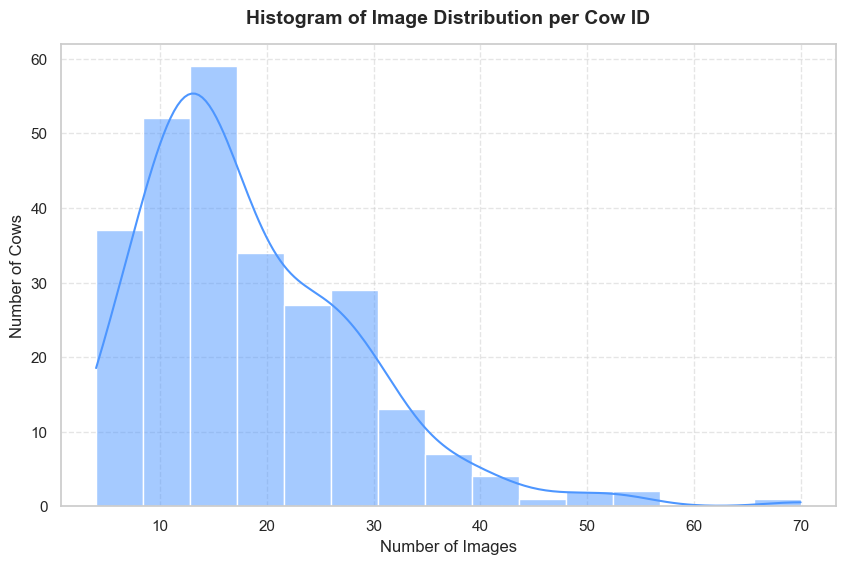

Displaying a few sample cattle muzzle images for visual analysis:


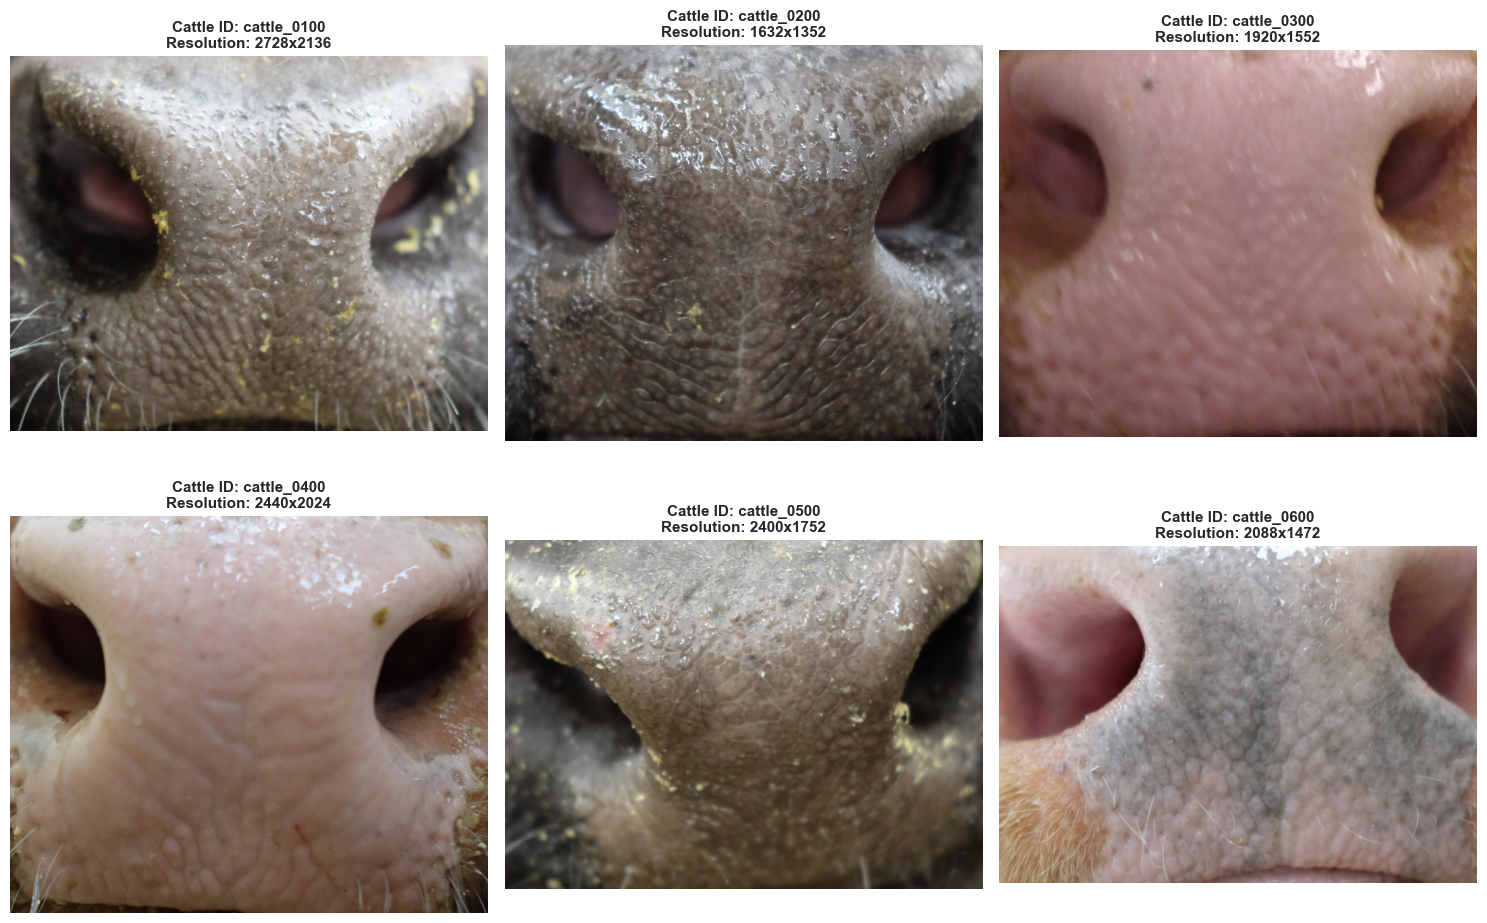

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=cattle_counts, x="image_count", bins=15, kde=True, color="#4D96FF")
plt.title("Histogram of Image Distribution per Cow ID", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Number of Cows", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("images_per_cow_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("Displaying a few sample cattle muzzle images for visual analysis:")
sample_classes = [c for c in list(class_images.keys()) if len(class_images[c]) > 0][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(sample_classes):
    img_path = class_images[cls][0]
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"Cattle ID: {cls}\nResolution: {img.size[0]}x{img.size[1]}", fontsize=11, fontweight='bold')
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("sample_cattle_muzzles.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Known/Unknown Separation by Threshold

We apply a threshold of `10` images. Cows with `< 10` images are classified as `unknown`, while cows with `>= 10` images are classified as `known` cattle. We export these groups to CSV files and then load/import them back.

In [5]:
threshold = 10
cattle_counts["status"] = np.where(cattle_counts["image_count"] < threshold, "unknown", "known")

known_df = cattle_counts[cattle_counts["status"] == "known"].copy()
unknown_df = cattle_counts[cattle_counts["status"] == "unknown"].copy()

print("=" * 60)
print(f"THRESHOLD RESULTS (Threshold = {threshold} images)")
print("=" * 60)
print(f"Total Known Cattle:   {len(known_df)} cows")
print(f"Total Unknown Cattle: {len(unknown_df)} cows")
print(f"Known Cattle Images:   {known_df['image_count'].sum()} images")
print(f"Unknown Cattle Images: {unknown_df['image_count'].sum()} images")
print(f"Total Dataset Images:  {cattle_counts['image_count'].sum()} images")
print("=" * 60)

print("\nUnknown Cattle and corresponding image counts:")
if len(unknown_df) > 0:
    print(unknown_df[["cattle_id", "image_count"]].to_string(index=False))
else:
    print("No cows have less than 10 images in this dataset configuration.")

known_df.to_csv("known_cows.csv", index=False)
unknown_df.to_csv("unknown_cows.csv", index=False)
print("\nSuccessfully exported 'known_cows.csv' and 'unknown_cows.csv'.")

print("\nRe-importing and printing 'known_cows.csv' preview:")
imported_known_df = pd.read_csv("known_cows.csv")
print(imported_known_df.head(10))

print("\nRe-importing and printing 'unknown_cows.csv' preview:")
imported_unknown_df = pd.read_csv("unknown_cows.csv")
print(imported_unknown_df.head(10))

THRESHOLD RESULTS (Threshold = 10 images)
Total Known Cattle:   227 cows
Total Unknown Cattle: 41 cows
Known Cattle Images:   4656 images
Unknown Cattle Images: 267 images
Total Dataset Images:  4923 images

Unknown Cattle and corresponding image counts:
  cattle_id  image_count
cattle_0100            8
cattle_0400            7
cattle_1500            6
cattle_1900            8
cattle_2100            4
cattle_2200            6
cattle_2220            6
cattle_2740            8
cattle_2930            6
cattle_3400            7
cattle_3420            4
cattle_3802            8
cattle_4259            6
cattle_4399            7
cattle_4451            7
cattle_4549            4
cattle_4717            5
cattle_4995            6
cattle_5100            8
cattle_5143            9
cattle_5153            5
cattle_5208            4
cattle_5234            8
cattle_5282            6
cattle_5355            4
cattle_5477            9
cattle_5556            8
cattle_5630            4
cattle_5762         

## 5. Duplicate Image Detection

We check for identical image files using MD5 hashes to identify if there are any duplicate images across classes or within classes.

In [6]:
print("Scanning all image files for duplicate content...")
hash_map = {}

for cls, paths in class_images.items():
    for path in paths:
        try:
            with open(path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash not in hash_map:
                hash_map[file_hash] = []
            hash_map[file_hash].append(path)
        except Exception as e:
            print(f"Error processing file '{path}': {e}")

duplicate_groups = {h: p for h, p in hash_map.items() if len(p) > 1}

print("\n" + "=" * 60)
print("DUPLICATE IMAGES ANALYSIS REPORT")
print("=" * 60)
if not duplicate_groups:
    print("No exact duplicate images found in the dataset.")
else:
    print(f"Found {len(duplicate_groups)} duplicate image groups (total {sum(len(p) for p in duplicate_groups.values())} files):")
    for i, (h, p) in enumerate(list(duplicate_groups.items())[:10]):
        print(f"\nDuplicate Group {i+1} (MD5: {h}):")
        for fp in p:
            print(f"  - {fp}")
    if len(duplicate_groups) > 10:
        print(f"\n... and {len(duplicate_groups) - 10} more duplicate groups.")
print("=" * 60)

Scanning all image files for duplicate content...



DUPLICATE IMAGES ANALYSIS REPORT
No exact duplicate images found in the dataset.


## 6. Train/Validation/Test Split

We perform a split on the dataset images:
- **Known cows' images**: 70% Train, 15% Validation, and 15% Test (performed per known class to maintain class representation).
- **Unknown cows' images**: 100% placed into the test set (as they are unknown and evaluated only during testing).
We save the final split mappings to `muzzle_dataset_split.csv` and load them back.

In [7]:
np.random.seed(42)

split_records = []
known_ids = set(known_df["cattle_id"].tolist())
unknown_ids = set(unknown_df["cattle_id"].tolist())

for cls, paths in class_images.items():
    paths = sorted(paths)
    
    if cls in known_ids:
        n = len(paths)
        indices = np.arange(n)
        np.random.shuffle(indices)
        
        n_train = int(round(0.70 * n))
        n_val = int(round(0.15 * n))
        n_test = n - n_train - n_val
        
        if n >= 3:
            if n_train == 0: n_train, n_test = 1, n_test - 1
            if n_val == 0: n_val, n_test = 1, n_test - 1
            if n_test == 0: n_test, n_train = 1, n_train - 1
            
        train_idx = set(indices[:n_train])
        val_idx = set(indices[n_train:n_train+n_val])
        test_idx = set(indices[n_train+n_val:])
        
        for idx, path in enumerate(paths):
            if idx in train_idx:
                split = "train"
            elif idx in val_idx:
                split = "val"
            else:
                split = "test"
            split_records.append({
                "file_path": path,
                "cattle_id": cls,
                "status": "known",
                "split": split
            })
    elif cls in unknown_ids:
        for path in paths:
            split_records.append({
                "file_path": path,
                "cattle_id": cls,
                "status": "unknown",
                "split": "test"
            })

split_df = pd.DataFrame(split_records)
split_csv_path = "muzzle_dataset_split.csv"
split_df.to_csv(split_csv_path, index=False)
print(f"Dataset split mapping exported to '{split_csv_path}'.")

imported_splits = pd.read_csv(split_csv_path)
print("\nPreview of re-imported splits (first 10 rows):")
print(imported_splits.head(10))

Dataset split mapping exported to 'muzzle_dataset_split.csv'.

Preview of re-imported splits (first 10 rows):
                                           file_path    cattle_id   status  \
0  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
1  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
2  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
3  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
4  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
5  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
6  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
7  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0100  unknown   
8  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0200    known   
9  BeefCattle_Muzzle_Individualized/BeefCattle_Mu...  cattle_0200    known   

   split  
0   test  
1   test 

## 7. Split Integrity Analysis

We analyze known cows to identify which cows are fully represented in all three splits versus which have missing splits. We also compute overall statistics between known and unknown categories across splits.

In [8]:
known_splits = split_df[split_df["status"] == "known"]
cow_splits = known_splits.groupby(["cattle_id", "split"]).size().unstack(fill_value=0)

cows_with_all_splits = cow_splits[
    (cow_splits["train"] > 0) & 
    (cow_splits["val"] > 0) & 
    (cow_splits["test"] > 0)
].index.tolist()

cows_with_missing_splits = cow_splits[
    (cow_splits["train"] == 0) | 
    (cow_splits["val"] == 0) | 
    (cow_splits["test"] == 0)
].index.tolist()

print("=" * 60)
print("KNOWN COWS SPLIT REPRESENTATION")
print("=" * 60)
print(f"Known cows represented in ALL 3 splits (Train, Val, Test): {len(cows_with_all_splits)}")
print(f"Known cows missing from at least one split:            {len(cows_with_missing_splits)}")
print("=" * 60)

if len(cows_with_missing_splits) > 0:
    print("\nDetails for known cows with missing splits:")
    print(cow_splits.loc[cows_with_missing_splits])
else:
    print("\nAll known cows have at least one image in each of Train, Val, and Test splits!")

print("\n" + "=" * 60)
print("OVERALL DATASET DISTRIBUTION BETWEEN KNOWN & UNKNOWN")
print("=" * 60)
distribution = split_df.groupby(["status", "split"]).size().unstack(fill_value=0)
distribution["total_images"] = distribution.sum(axis=1)
print(distribution)
print("=" * 60)

KNOWN COWS SPLIT REPRESENTATION
Known cows represented in ALL 3 splits (Train, Val, Test): 227
Known cows missing from at least one split:            0

All known cows have at least one image in each of Train, Val, and Test splits!

OVERALL DATASET DISTRIBUTION BETWEEN KNOWN & UNKNOWN
split    test  train  val  total_images
status                                 
known     697   3250  709          4656
unknown   267      0    0           267
